<a href="https://colab.research.google.com/github/eng20260311/AIFFEL_quest_eng/blob/master/NLP/NLP01/seq2seq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!tar -xzvf korean-english-park.train.tar.gz
!pip install tensorflow

korean-english-park.train.en
korean-english-park.train.ko


In [8]:
import os, re, time, random
import numpy as np
import tensorflow as tf

SEED = 1234
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

KO_PATH = "korean-english-park.train.ko"
EN_PATH = "korean-english-park.train.en"

with open(KO_PATH, encoding="utf-8") as f:
    raw_ko = [l.rstrip("\n") for l in f]
with open(EN_PATH, encoding="utf-8") as f:
    raw_en = [l.rstrip("\n") for l in f]

assert len(raw_ko) == len(raw_en), "두 파일은 줄 단위로 정렬돼 있어야 합니다."
print(f"loaded {len(raw_ko):,} parallel pairs")
print("ko sample:", raw_ko[0])
print("en sample:", raw_en[0])

loaded 94,123 parallel pairs
ko sample: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
en sample: Much of personal computing is about "can you top this?"


In [9]:
# Step 2-a. 중복 제거 — set 자료형으로 (쌍을 통째로 키로!)
seen = set()
cleaned_corpus = []
for k, e in zip(raw_ko, raw_en):
    key = (k, e)
    if key in seen:        # 같은 쌍이 또 나오면 스킵
        continue
    seen.add(key)
    cleaned_corpus.append((k, e))

print(f"after dedup: {len(cleaned_corpus):,} pairs "
      f"(removed {len(raw_ko)-len(cleaned_corpus):,})")

after dedup: 78,968 pairs (removed 15,155)


In [10]:
# Step 2-b. 전처리 함수 — 한·영 분리 정의
# 강의 코드의 preprocessing()은 한글이 모두 정규식으로 제거되어 사용 불가.
# 한국어용 정규식을 별도로 정의합니다.

def preprocess_eng(s, with_tags=False):
    s = s.lower().strip()
    s = re.sub(r"([?.!,])", r" \1 ", s)
    s = re.sub(r'[" "]+', " ", s)
    s = re.sub(r"[^a-zA-Z?.!,]+", " ", s)
    s = s.strip()
    if with_tags:
        s = "<start> " + s + " <end>"
    return s

# Hangul Unicode blocks: AC00-D7A3 음절, 1100-11FF / 3130-318F 자모
HANGUL = r"\uAC00-\uD7A3\u1100-\u11FF\u3130-\u318F"

def preprocess_kor(s):
    s = s.strip()
    s = re.sub(r"([?.!,])", r" \1 ", s)
    s = re.sub(r"[\"' ]+", " ", s)
    s = re.sub(rf"[^{HANGUL}?.!,]+", " ", s)
    return s.strip()

print(preprocess_kor("안녕하세요!! Hello~~ 오바마는 대통령이다."))
print(preprocess_eng("Hello, World!", with_tags=True))

안녕하세요 ! ! 오바마는 대통령이다 .
<start> hello , world ! <end>


In [11]:
!curl -s https://githubusercontent.com | bash

In [12]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.0/438.0 kB 43.4 MB/s eta 0:00:00


In [13]:
pip install python-mecab-ko

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 14.4 MB/s eta 0:00:00


In [14]:
import mecab
print(mecab.MeCab().morphs("안녕 한국어 잘 되니?"))

['안녕', '한국어', '잘', '되', '니', '?']


In [15]:
import mecab
mecab = mecab.MeCab()

print(mecab.morphs("Mecab 설치가 완료되었습니다!"))

['Mecab', '설치', '가', '완료', '되', '었', '습니다', '!']


In [16]:
# Step 2-c. 한국어 토큰화는 KoNLPy의 mecab 사용
#   - KoNLPy의 from konlpy.tag import Mecab 가 권장이지만,
#     시스템에 mecab이 없는 경우 python-mecab-ko 를 대신 사용해도 동일한 .morphs() 인터페이스 제공.
try:
    import mecab
    mecab = mecab.MeCab()
except Exception:
    import mecab as _mk
    mecab = _mk.MeCab()           # python-mecab-ko, 사전 내장

print(mecab.morphs("오바마는 미국의 대통령이다."))

['오바마', '는', '미국', '의', '대통령', '이', '다', '.']


In [17]:
# Step 2-d. 영문에 <start>/<end> 토큰 부착, 영문은 split()으로,
#           한글은 mecab.morphs()로 토큰화. 토큰 길이 <= 40 필터링.
MAX_LEN = 40

eng_corpus, kor_corpus = [], []
for ko, en in cleaned_corpus:
    ko_clean = preprocess_kor(ko)
    en_clean = preprocess_eng(en, with_tags=True)
    if not ko_clean or not en_clean:
        continue
    ko_tokens = mecab.morphs(ko_clean)
    en_tokens = en_clean.split()
    if len(ko_tokens) <= MAX_LEN and len(en_tokens) <= MAX_LEN:
        kor_corpus.append(ko_tokens)
        eng_corpus.append(en_tokens)

print(f"kept pairs: {len(kor_corpus):,}")
print("ko:", kor_corpus[0])
print("en:", eng_corpus[0])

kept pairs: 63,131
ko: ['개인', '용', '컴퓨터', '사용', '의', '상당', '부분', '은', '이것', '보다', '뛰어날', '수', '있', '느냐', '?']
en: ['<start>', 'much', 'of', 'personal', 'computing', 'is', 'about', 'can', 'you', 'top', 'this', '?', '<end>']


In [18]:
# Step 3. 토큰화 → 정수 텐서로
def tokenize(corpus, num_words=None):
    tok = tf.keras.preprocessing.text.Tokenizer(
        num_words=num_words, filters="", oov_token="<unk>"
    )
    tok.fit_on_texts(corpus)
    seqs = tok.texts_to_sequences(corpus)
    tensor = tf.keras.preprocessing.sequence.pad_sequences(seqs, padding="post")
    return tensor, tok

# 단어 수 — 실험을 통해 조정 (사양: 최소 10,000 이상)
KO_VOCAB = 20000
EN_VOCAB = 20000

kor_tensor, kor_tokenizer = tokenize(kor_corpus, num_words=KO_VOCAB)
eng_tensor, eng_tokenizer = tokenize(eng_corpus, num_words=EN_VOCAB)

print("kor_tensor", kor_tensor.shape, "ko vocab:", len(kor_tokenizer.word_index))
print("eng_tensor", eng_tensor.shape, "en vocab:", len(eng_tokenizer.word_index))

kor_tensor (63131, 40) ko vocab: 37081
eng_tensor (63131, 40) en vocab: 38540


In [19]:
# Step 4. 모델 설계 — Bahdanau Attention 기반 Encoder-Decoder
EMB_DIM = 256
HIDDEN  = 512
BATCH   = 64

KO_VOCAB_SIZE = min(KO_VOCAB, len(kor_tokenizer.word_index)) + 1
EN_VOCAB_SIZE = min(EN_VOCAB, len(eng_tokenizer.word_index)) + 1

class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, emb_dim, units):
        super().__init__()
        self.emb = tf.keras.layers.Embedding(vocab_size, emb_dim)
        self.gru = tf.keras.layers.GRU(units, return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer="glorot_uniform")
    def call(self, x):
        x = self.emb(x)
        out, state = self.gru(x)
        return out, state


class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V  = tf.keras.layers.Dense(1)
    def call(self, query, values):
        q = tf.expand_dims(query, 1)
        score = self.V(tf.nn.tanh(self.W1(values) + self.W2(q)))
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * values, axis=1)
        return context, weights


class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, emb_dim, units):
        super().__init__()
        self.emb = tf.keras.layers.Embedding(vocab_size, emb_dim)
        self.gru = tf.keras.layers.GRU(units, return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer="glorot_uniform")
        self.fc = tf.keras.layers.Dense(vocab_size)
        self.attention = BahdanauAttention(units)
    def call(self, x, hidden, enc_out):
        context, weights = self.attention(hidden, enc_out)
        x = self.emb(x)
        x = tf.concat([tf.expand_dims(context, 1), x], axis=-1)
        out, state = self.gru(x)
        out = tf.reshape(out, (-1, out.shape[2]))
        logits = self.fc(out)
        return logits, state, weights


encoder = Encoder(KO_VOCAB_SIZE, EMB_DIM, HIDDEN)
decoder = Decoder(EN_VOCAB_SIZE, EMB_DIM, HIDDEN)
optimizer = tf.keras.optimizers.Adam()
loss_obj = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction="none"
)

def loss_fn(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    l = loss_obj(real, pred)
    mask = tf.cast(mask, dtype=l.dtype)
    return tf.reduce_mean(l * mask)

In [20]:
# Step 5-a. 훈련 루프 (eval_step 없음, teacher forcing)
START = eng_tokenizer.word_index["<start>"]

@tf.function
def train_step(src, tgt):
    loss = 0.0
    with tf.GradientTape() as tape:
        enc_out, enc_state = encoder(src)
        dec_state = enc_state
        dec_input = tf.expand_dims([START] * src.shape[0], 1)
        for t in range(1, tgt.shape[1]):
            logits, dec_state, _ = decoder(dec_input, dec_state, enc_out)
            loss += loss_fn(tgt[:, t], logits)
            dec_input = tf.expand_dims(tgt[:, t], 1)        # teacher forcing
    batch_loss = loss / tf.cast(tgt.shape[1], tf.float32)
    grads = tape.gradient(loss,
        encoder.trainable_variables + decoder.trainable_variables)
    optimizer.apply_gradients(zip(grads,
        encoder.trainable_variables + decoder.trainable_variables))
    return batch_loss


def translate(sentence, return_attention=False, max_len=None):
    if max_len is None:
        max_len = eng_tensor.shape[1]
    s = preprocess_kor(sentence)
    tokens = mecab.morphs(s)
    seq = kor_tokenizer.texts_to_sequences([tokens])
    if not seq[0]:
        return "", np.zeros((0, 0)), tokens
    seq = tf.keras.preprocessing.sequence.pad_sequences(
        seq, maxlen=kor_tensor.shape[1], padding="post"
    )
    seq = tf.convert_to_tensor(seq)

    enc_out, enc_state = encoder(seq)
    dec_state = enc_state
    dec_input = tf.expand_dims([START], 0)

    out_words, attn_rows = [], []
    for _ in range(max_len):
        logits, dec_state, weights = decoder(dec_input, dec_state, enc_out)
        attn_rows.append(tf.reshape(weights, (-1,)).numpy())
        pred_id = int(tf.argmax(logits[0]).numpy())
        word = eng_tokenizer.index_word.get(pred_id, "")
        if word == "<end>" or word == "":
            break
        out_words.append(word)
        dec_input = tf.expand_dims([pred_id], 0)

    text = " ".join(out_words)
    if return_attention:
        return text, np.stack(attn_rows, axis=0), tokens
    return text

In [21]:
# Step 5-b. 학습 시작
EPOCHS = 10
SAMPLES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요해.",
    "일곱 명의 사망자가 발생했다.",
]

ds = (tf.data.Dataset.from_tensor_slices((kor_tensor, eng_tensor))
      .shuffle(len(kor_tensor), seed=SEED)
      .batch(BATCH, drop_remainder=True))

history = []
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    total = 0.0; n = 0
    for src, tgt in ds:
        total += float(train_step(src, tgt)); n += 1
    avg = total / max(n, 1)
    history.append(avg)
    print(f"epoch {epoch:2d} | loss {avg:6.4f} | {time.time()-t0:5.1f}s")
    for s in SAMPLES:
        print(f"   {s}  ->  {translate(s)!r}")

epoch  1 | loss 3.4063 | 296.7s
   오바마는 대통령이다.  ->  'the u . s .'
   시민들은 도시 속에 산다.  ->  'the u . s .'
   커피는 필요해.  ->  'the u . s .'
   일곱 명의 사망자가 발생했다.  ->  'the u . s .'
epoch  2 | loss 3.0520 | 280.2s
   오바마는 대통령이다.  ->  'obama s .'
   시민들은 도시 속에 산다.  ->  'the <unk> .'
   커피는 필요해.  ->  'the <unk> .'
   일곱 명의 사망자가 발생했다.  ->  'the united states .'
epoch  3 | loss 2.8162 | 280.5s
   오바마는 대통령이다.  ->  'obama is the first time .'
   시민들은 도시 속에 산다.  ->  'the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> .'
   커피는 필요해.  ->  'the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the'
   일곱 명의 사망자가 발생했다.  ->  'the two men were killed in the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the'
epoch  4 | loss 2.6143 | 280.9s
   오바마는 대통령이다.  ->  'obama

/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 47161 (\N

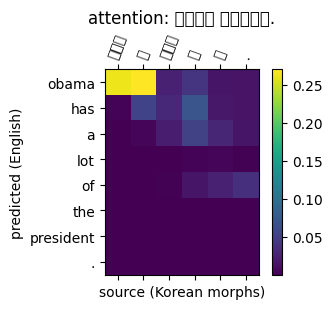

/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 46308 (\N{HANGUL SYLLABLE DEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 50640 (\

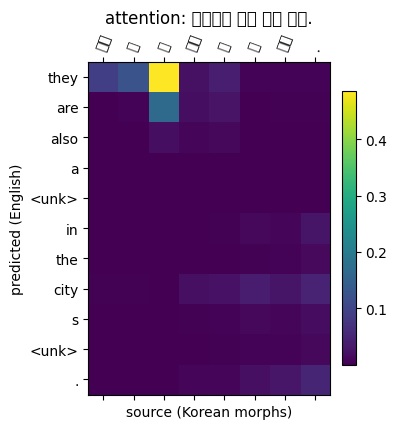

/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.p

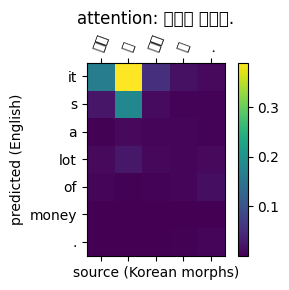

/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548/1519455452.py:30: UserWarning: Glyph 51088 

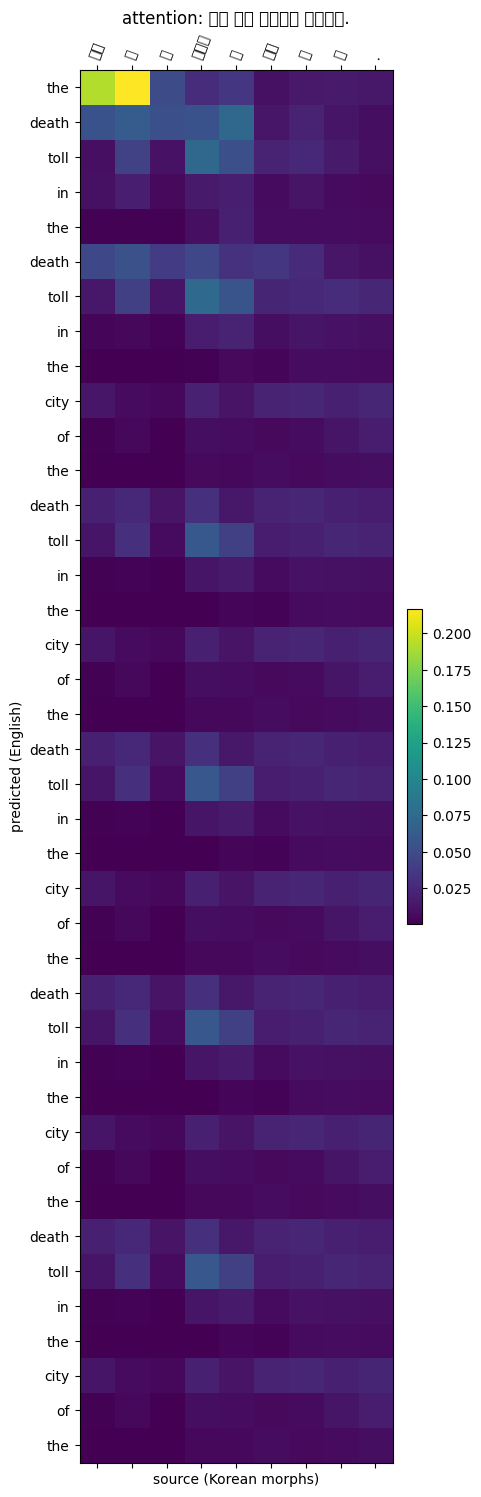

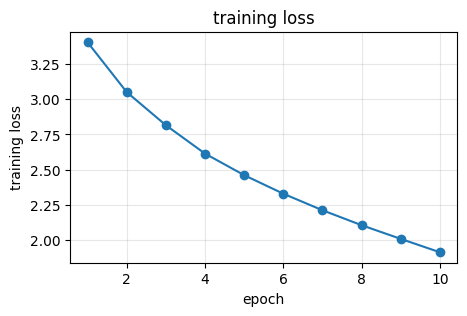

In [22]:
# Step 5-c. Attention map 시각화
import os
import matplotlib.pyplot as plt
import matplotlib, matplotlib.font_manager as fm
for p in ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
          "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"]:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        matplotlib.rcParams["font.family"] = (
            "Noto Sans CJK JP" if "Noto" in p else "NanumGothic"
        )
        break
matplotlib.rcParams["axes.unicode_minus"] = False

def plot_attention(sentence):
    text, attn, src_toks = translate(sentence, return_attention=True)
    if not text:
        print("(empty)"); return
    pred = text.split()
    attn = attn[:len(pred), :len(src_toks)]
    fig, ax = plt.subplots(figsize=(max(4, len(src_toks)*0.5),
                                    max(3, len(pred)*0.4)))
    im = ax.matshow(attn, cmap="viridis")
    ax.set_xticks(range(len(src_toks))); ax.set_xticklabels(src_toks, rotation=70)
    ax.set_yticks(range(len(pred)));     ax.set_yticklabels(pred)
    ax.set_xlabel("source (Korean morphs)")
    ax.set_ylabel("predicted (English)")
    ax.set_title(f"attention: {sentence}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

SAMPLES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요해.",
    "일곱 명의 사망자가 발생했다.",
]


for s in SAMPLES:
    plot_attention(s)

plt.figure(figsize=(5,3))
plt.plot(range(1, len(history)+1), history, marker="o")
plt.xlabel("epoch"); plt.ylabel("training loss"); plt.title("training loss")
plt.grid(True, alpha=0.3); plt.show()

In [23]:
# Step 5-b. 학습 시작
EPOCHS = 15
SAMPLES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요해.",
    "일곱 명의 사망자가 발생했다.",
]

ds = (tf.data.Dataset.from_tensor_slices((kor_tensor, eng_tensor))
      .shuffle(len(kor_tensor), seed=SEED)
      .batch(BATCH, drop_remainder=True))

history = []
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    total = 0.0; n = 0
    for src, tgt in ds:
        total += float(train_step(src, tgt)); n += 1
    avg = total / max(n, 1)
    history.append(avg)
    print(f"epoch {epoch:2d} | loss {avg:6.4f} | {time.time()-t0:5.1f}s")
    for s in SAMPLES:
        print(f"   {s}  ->  {translate(s)!r}")

epoch  1 | loss 1.8283 | 281.6s
   오바마는 대통령이다.  ->  'obama says he s a lot of the president .'
   시민들은 도시 속에 산다.  ->  'they have been a <unk> in the town s <unk> .'
   커피는 필요해.  ->  'it s a lot of the food'
   일곱 명의 사망자가 발생했다.  ->  'the death toll was killed in the capital .'
epoch  2 | loss 1.7477 | 280.4s
   오바마는 대통령이다.  ->  'obama has a strong president .'
   시민들은 도시 속에 산다.  ->  'they are in the town of the city s <unk> .'
   커피는 필요해.  ->  'it s a lot of uninterrupted .'
   일곱 명의 사망자가 발생했다.  ->  'a total of the death toll was killed in the city .'
epoch  3 | loss 1.6818 | 280.5s
   오바마는 대통령이다.  ->  'obama says he s a great honor .'
   시민들은 도시 속에 산다.  ->  'they have been <unk> around the town s <unk> .'
   커피는 필요해.  ->  'the lights are <unk> .'
   일곱 명의 사망자가 발생했다.  ->  'the number of people were killed in the city of the number of people were killed in the city of the number of people were killed in the city of the number of people were killed in the city of'
epoch  4 | loss 1.6129 |

In [1]:
# Step 5-b. 학습 시작
EPOCHS = 30
SAMPLES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요해.",
    "일곱 명의 사망자가 발생했다.",
]

ds = (tf.data.Dataset.from_tensor_slices((kor_tensor, eng_tensor))
      .shuffle(len(kor_tensor), seed=SEED)
      .batch(BATCH, drop_remainder=True))

history = []
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    total = 0.0; n = 0
    for src, tgt in ds:
        total += float(train_step(src, tgt)); n += 1
    avg = total / max(n, 1)
    history.append(avg)
    print(f"epoch {epoch:2d} | loss {avg:6.4f} | {time.time()-t0:5.1f}s")
    for s in SAMPLES:
        print(f"   {s}  ->  {translate(s)!r}")

NameError: name 'tf' is not defined

GPU사용량 제한으로 에포크 26에서 멈춰버림 : loss함수가 0.62정도로 마지막 문장인 '일곱명의 사망자가 발생했다'에서 완벽한 번역을 보여줬다.

In [ ]:
# Step 5-c. Attention map 시각화
import os
import matplotlib.pyplot as plt
import matplotlib, matplotlib.font_manager as fm
for p in ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
          "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"]:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        matplotlib.rcParams["font.family"] = (
            "Noto Sans CJK JP" if "Noto" in p else "NanumGothic"
        )
        break
matplotlib.rcParams["axes.unicode_minus"] = False

def plot_attention(sentence):
    text, attn, src_toks = translate(sentence, return_attention=True)
    if not text:
        print("(empty)"); return
    pred = text.split()
    attn = attn[:len(pred), :len(src_toks)]
    fig, ax = plt.subplots(figsize=(max(4, len(src_toks)*0.5),
                                    max(3, len(pred)*0.4)))
    im = ax.matshow(attn, cmap="viridis")
    ax.set_xticks(range(len(src_toks))); ax.set_xticklabels(src_toks, rotation=70)
    ax.set_yticks(range(len(pred)));     ax.set_yticklabels(pred)
    ax.set_xlabel("source (Korean morphs)")
    ax.set_ylabel("predicted (English)")
    ax.set_title(f"attention: {sentence}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()


for s in SAMPLES:
    plot_attention(s)

plt.figure(figsize=(5,3))
plt.plot(range(1, len(history)+1), history, marker="o")
plt.xlabel("epoch"); plt.ylabel("training loss"); plt.title("training loss")
plt.grid(True, alpha=0.3); plt.show()